<a href="https://colab.research.google.com/github/MaggieHDez/ClassFiles/blob/RN/Ejemplo_RNN_imdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (25000, 200),  Test: (25000, 200)

Entrenando modelo: SimpleRNN
Epoch 1/10
333/333 - 10s - 29ms/step - accuracy: 0.6899 - loss: 0.5715 - val_accuracy: 0.8187 - val_loss: 0.4231
Epoch 2/10
333/333 - 7s - 22ms/step - accuracy: 0.8407 - loss: 0.3647 - val_accuracy: 0.8123 - val_loss: 0.4296
Epoch 3/10
333/333 - 11s - 32ms/step - accuracy: 0.8960 - loss: 0.2590 - val_accuracy: 0.8453 - val_loss: 0.3814
Epoch 4/10
333/333 - 10s - 30ms/step - accuracy: 0.9332 - loss: 0.1813 - val_accuracy: 0.8328 - val_loss: 0.4489
Epoch 5/10
333/333 - 5s - 16ms/step - accuracy: 0.9589 - loss: 0.1152 - val_accuracy: 0.8189 - val_loss: 0.5530
Epoch 6/10
333/333 - 5s - 16ms/step - accuracy: 0.9718 - loss: 0.0826 - val_accuracy: 0.7995 - val_loss: 0.6289
Epoch 7/10
333/333 - 10s - 31ms/step - accuracy: 0.9842 - loss: 0.0499 - val_accuracy: 0.8088 - val_loss: 0.6887
Epoch 8/10
333/333 - 5s - 16ms/step - accuracy: 0.9372 - loss: 0.1580 - val_accuracy: 0.81

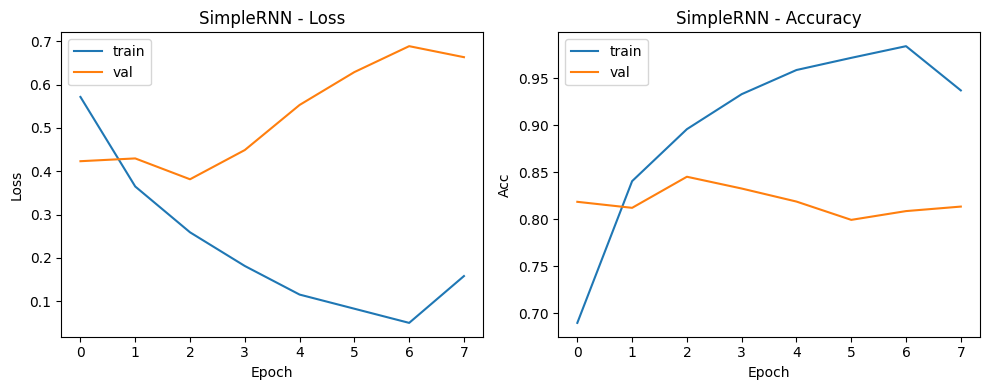

[SimpleRNN] Accuracy: 0.8411 | Loss: 0.3777 | Tiempo/época: 8.00 s

Entrenando modelo: LSTM
Epoch 1/10
333/333 - 7s - 22ms/step - accuracy: 0.7921 - loss: 0.4265 - val_accuracy: 0.8707 - val_loss: 0.3101
Epoch 2/10
333/333 - 3s - 10ms/step - accuracy: 0.9038 - loss: 0.2482 - val_accuracy: 0.8616 - val_loss: 0.3473
Epoch 3/10
333/333 - 3s - 10ms/step - accuracy: 0.9326 - loss: 0.1779 - val_accuracy: 0.8675 - val_loss: 0.3216
Epoch 4/10
333/333 - 4s - 12ms/step - accuracy: 0.9492 - loss: 0.1381 - val_accuracy: 0.8725 - val_loss: 0.4014
Epoch 5/10
333/333 - 3s - 10ms/step - accuracy: 0.9654 - loss: 0.0983 - val_accuracy: 0.8640 - val_loss: 0.4448
Epoch 6/10
333/333 - 5s - 16ms/step - accuracy: 0.9727 - loss: 0.0765 - val_accuracy: 0.8373 - val_loss: 0.5676


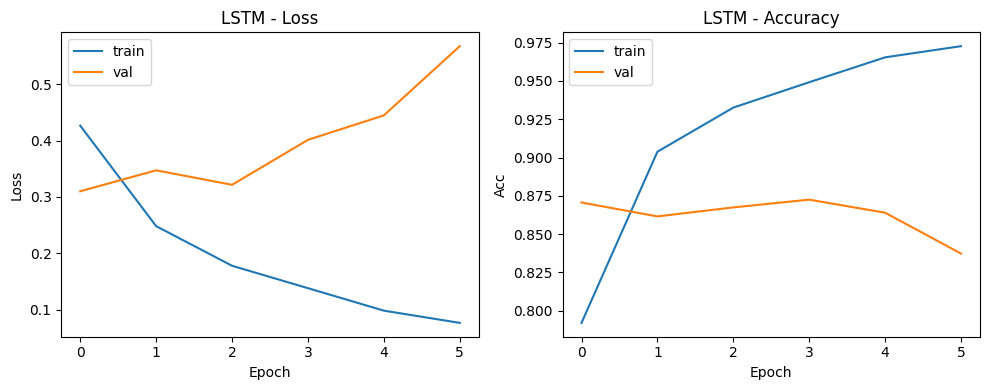

[LSTM] Accuracy: 0.8711 | Loss: 0.3072 | Tiempo/época: 4.45 s

Entrenando modelo: GRU
Epoch 1/10
333/333 - 5s - 14ms/step - accuracy: 0.7910 - loss: 0.4329 - val_accuracy: 0.8328 - val_loss: 0.3749
Epoch 2/10
333/333 - 5s - 16ms/step - accuracy: 0.9022 - loss: 0.2502 - val_accuracy: 0.8715 - val_loss: 0.3423
Epoch 3/10
333/333 - 5s - 14ms/step - accuracy: 0.9323 - loss: 0.1792 - val_accuracy: 0.8672 - val_loss: 0.3189
Epoch 4/10
333/333 - 3s - 10ms/step - accuracy: 0.9574 - loss: 0.1193 - val_accuracy: 0.8699 - val_loss: 0.3630
Epoch 5/10
333/333 - 6s - 17ms/step - accuracy: 0.9747 - loss: 0.0733 - val_accuracy: 0.8645 - val_loss: 0.5182
Epoch 6/10
333/333 - 3s - 10ms/step - accuracy: 0.9845 - loss: 0.0475 - val_accuracy: 0.8579 - val_loss: 0.5226
Epoch 7/10
333/333 - 5s - 16ms/step - accuracy: 0.9911 - loss: 0.0288 - val_accuracy: 0.8560 - val_loss: 0.6325
Epoch 8/10
333/333 - 4s - 11ms/step - accuracy: 0.9925 - loss: 0.0226 - val_accuracy: 0.8611 - val_loss: 0.6656


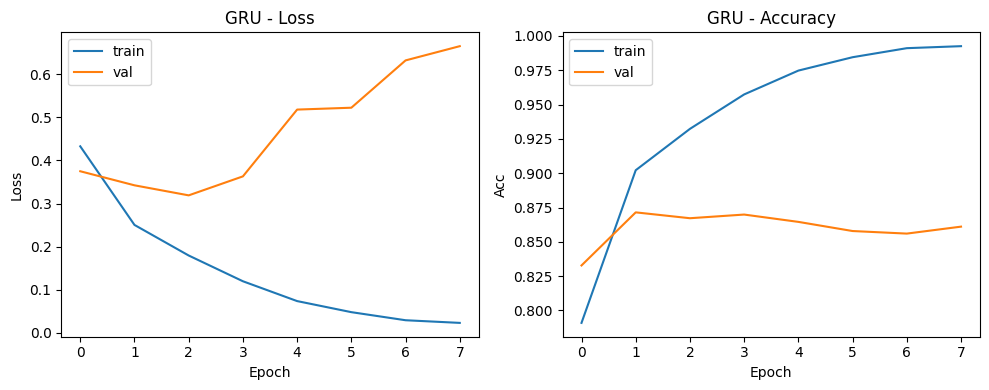

[GRU] Accuracy: 0.8658 | Loss: 0.3249 | Tiempo/época: 4.48 s

Resumen de resultados:
SimpleRNN -> Accuracy: 0.8411 | Loss: 0.3777 | Tiempo/época: 8.00 s
LSTM      -> Accuracy: 0.8711 | Loss: 0.3072 | Tiempo/época: 4.45 s
GRU       -> Accuracy: 0.8658 | Loss: 0.3249 | Tiempo/época: 4.48 s


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import time # para tomar el tiempo

#%%

VOCAB_SIZE   = 10000     # top palabras
MAX_LEN      = 200       # longitud fija de secuencia

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

# Padding / truncado para longitud fija
x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding="pre", truncating="pre")
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN, padding="pre", truncating="pre")

print(f"Train: {x_train.shape},  Test: {x_test.shape}")

#%%

# Clase creada para tomar el tiempo de las épocas
class TimeHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_time_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.time() - self.epoch_time_start)

    def average_epoch_time(self):
        return np.mean(self.times)

#%%

# Función para construir modelo RNN/LSTM/GRU
def build_model(cell_type='SimpleRNN'):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(MAX_LEN,), dtype='int32'))
    model.add(keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128))

    # Para cambiar entre RNN, LSTM o GRU
    if cell_type == 'SimpleRNN':
        model.add(layers.SimpleRNN(64))                     # RNN básica
    elif cell_type == 'LSTM':
        model.add(layers.LSTM(64))
    elif cell_type == 'GRU':
        model.add(layers.GRU(64))

    model.add(layers.Dense(1, activation="sigmoid"))     # binaria
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

#%%

# Función para entrenamient y evaluación
def entrenamiento_y_evaluacion(model_type, x_train, y_train, x_test, y_test, callbacks, epochs=10, batch_size=64):
    print(f"\nEntrenando modelo: {model_type}")
    model = build_model(model_type)
    time_callback = TimeHistory()

    history = model.fit(
        x_train, y_train,
        validation_split=0.15,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[*callbacks, time_callback],
        verbose=2
    )

    # Evaluar sobre el conjunto de prueba
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    avg_time = time_callback.average_epoch_time()

    # Mostrar gráficas
    plot_history(history, model_type)

    # Imprimir resultados
    print(f"[{model_type}] Accuracy: {test_acc:.4f} | Loss: {test_loss:.4f} | Tiempo/época: {avg_time:.2f} s")

    # Devolver resultados para el resumen final
    return {
        'model': model,
        'history': history,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'avg_time': avg_time
    }

#%%

def plot_history(hist, title):
    fig, ax = plt.subplots(1,2, figsize=(10,4))
    ax[0].plot(hist.history["loss"], label="train")
    ax[0].plot(hist.history["val_loss"], label="val")
    ax[0].set_title(f"{title} - Loss")
    ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend()
    ax[1].plot(hist.history["accuracy"], label="train")
    ax[1].plot(hist.history["val_accuracy"], label="val")
    ax[1].set_title(f"{title} - Accuracy")
    ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Acc"); ax[1].legend()
    plt.tight_layout(); plt.show()

#%%

# Definir callback
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

# Entrenamiento de los 3 modelos
resultados_rnn  = entrenamiento_y_evaluacion("SimpleRNN", x_train, y_train, x_test, y_test, callbacks)
resultados_lstm = entrenamiento_y_evaluacion("LSTM",      x_train, y_train, x_test, y_test, callbacks)
resultados_gru  = entrenamiento_y_evaluacion("GRU",       x_train, y_train, x_test, y_test, callbacks)

#%%

# Resumen comparativo final
print("\nResumen de resultados:")
print(f"SimpleRNN -> Accuracy: {resultados_rnn['test_acc']:.4f} | Loss: {resultados_rnn['test_loss']:.4f} | Tiempo/época: {resultados_rnn['avg_time']:.2f} s")
print(f"LSTM      -> Accuracy: {resultados_lstm['test_acc']:.4f} | Loss: {resultados_lstm['test_loss']:.4f} | Tiempo/época: {resultados_lstm['avg_time']:.2f} s")
print(f"GRU       -> Accuracy: {resultados_gru['test_acc']:.4f} | Loss: {resultados_gru['test_loss']:.4f} | Tiempo/época: {resultados_gru['avg_time']:.2f} s")
